In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import nltk
import re
import gensim
import matplotlib.pyplot as plt
%matplotlib inline

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')

from nltk.tokenize import word_tokenize
from string import punctuation 
from nltk.corpus import stopwords
from nltk.stem.wordnet import WordNetLemmatizer
from nltk.stem import SnowballStemmer

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

from keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.layers import Activation, Dense, Dropout, Embedding, Flatten, Conv1D, MaxPooling1D, LSTM, Bidirectional, SimpleRNN
from keras import utils
from keras.callbacks import ReduceLROnPlateau, EarlyStopping

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Unzipping corpora/wordnet.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


Using TensorFlow backend.


**READING THE DATASET**

In [2]:
train_data = pd.read_csv("train.txt",delimiter=',')
train_data.to_csv('traindata.csv')
test_data = pd.read_csv("test_samples.txt",delimiter=',')
test_data.to_csv('testdata.csv')

**ANALYSING DATASET**

In [3]:
print(train_data.shape)
print(test_data.shape)

(21465, 3)
(5398, 2)


In [4]:
print(train_data.head())
print(test_data.head())

             tweet_id  ...                                         tweet_text
0  264183816548130816  ...  Gas by my house hit $3.39!!!! I\u2019m going t...
1  263405084770172928  ...  Theo Walcott is still shit\u002c watch Rafa an...
2  262163168678248449  ...  its not that I\u2019m a GSP fan\u002c i just h...
3  264249301910310912  ...  Iranian general says Israel\u2019s Iron Dome c...
4  262682041215234048  ...  Tehran\u002c Mon Amour: Obama Tried to Establi...

[5 rows x 3 columns]
             tweet_id                                         tweet_text
0  264238274963451904  @jjuueellzz down in the Atlantic city, ventnor...
1  218775148495515649  Musical awareness: Great Big Beautiful Tomorro...
2  258965201766998017  On Radio786 100.4fm 7:10 Fri Oct 19 Labour ana...
3  262926411352903682  Kapan sih lo ngebuktiin,jan ngomong doang Susa...
4  171874368908050432  Excuse the connectivity of this live stream, f...


In [5]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21465 entries, 0 to 21464
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   tweet_id    21465 non-null  int64 
 1   sentiment   21465 non-null  object
 2   tweet_text  21465 non-null  object
dtypes: int64(1), object(2)
memory usage: 503.2+ KB


In [6]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5398 entries, 0 to 5397
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   tweet_id    5398 non-null   int64 
 1   tweet_text  5398 non-null   object
dtypes: int64(1), object(1)
memory usage: 84.5+ KB


In [7]:
train_data["tweet_text"][0]

'Gas by my house hit $3.39!!!! I\\u2019m going to Chapel Hill on Sat. :)'

In [8]:
test_data["tweet_text"][0]

"@jjuueellzz down in the Atlantic city, ventnor, margate, ocean city area. I'm just waiting for the coordinator to hopefully call me tomorrow"

In [9]:
train_data["sentiment"].value_counts()

positive    9064
neutral     9014
negative    3387
Name: sentiment, dtype: int64

In [10]:
train_data["sentiment"]

0        positive
1        negative
2        negative
3        negative
4         neutral
           ...   
21460     neutral
21461     neutral
21462     neutral
21463    positive
21464     neutral
Name: sentiment, Length: 21465, dtype: object

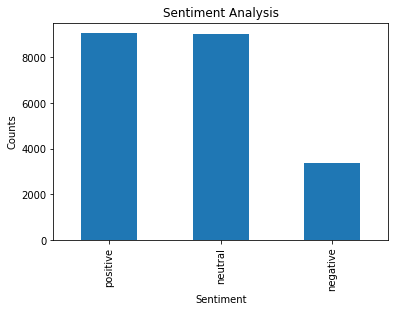

In [11]:
plt.title("Sentiment Analysis")
plt.xlabel("Sentiment")
plt.ylabel("Counts")
train_data["sentiment"].value_counts().plot(kind="bar")
plt.show()

**PROCESSING THE TWEET TEXT**

In [12]:
def processTweet(tweet):
    stop_words = set(stopwords.words('english') + list(punctuation) )
    stemmer = SnowballStemmer("english")
    tweet = tweet.lower() # convert text to lower-case
    tweet = re.sub('((www\.[^\s]+)|(https?://[^\s]+))', '', tweet) # remove URLs
    tweet = re.sub('@[^\s]+', '', tweet) # remove usernames
    tweet = re.sub(r'#([^\s]+)', r'\1', tweet) # remove the # in #hashtag
    tweet = re.sub('\\\\u([0-9]+)([a-z]+)','',tweet)
    tweet = word_tokenize(tweet) # remove repeated characters (helloooooooo into hello)
    lem=WordNetLemmatizer()
    for i in tweet:
      i = stemmer.stem(i)
    x = [word for word in tweet if word not in stop_words]
    x = ' '.join(x)
    return str(x)

train_data["tweet_text"]=train_data["tweet_text"].apply(processTweet)
test_data["tweet_text"]=test_data["tweet_text"].apply(processTweet)

In [13]:
print(train_data.head())

             tweet_id  ...                                         tweet_text
0  264183816548130816  ...           gas house hit 3.39 going chapel hill sat
1  263405084770172928  ...  theo walcott still shit watch rafa johnny deal...
2  262163168678248449  ...               gsp fan hate nick diaz wait february
3  264249301910310912  ...  iranian general says israel iron dome deal mis...
4  262682041215234048  ...  tehran mon amour obama tried establish ties mu...

[5 rows x 3 columns]


In [14]:
print(train_data["tweet_text"][0])

gas house hit 3.39 going chapel hill sat


In [15]:
print(test_data.head())

             tweet_id                                         tweet_text
0  264238274963451904  atlantic city ventnor margate ocean city area ...
1  218775148495515649  musical awareness great big beautiful tomorrow...
2  258965201766998017  radio786 100.4fm 7:10 fri oct 19 labour analys...
3  262926411352903682  kapan sih lo ngebuktiin jan ngomong doang susa...
4  171874368908050432  excuse connectivity live stream baba amr many ...


In [16]:
print(test_data["tweet_text"][0])

atlantic city ventnor margate ocean city area 'm waiting coordinator hopefully call tomorrow


In [17]:
X_train = train_data["tweet_text"]
Y_train = train_data["sentiment"]
X_test = test_data["tweet_text"]

In [19]:
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)

(21465,)
(21465,)
(5398,)


In [20]:
print(X_train[0])
print(Y_train[0])

gas house hit 3.39 going chapel hill sat
positive


In [21]:
labels = Y_train.unique().tolist()
labels

['positive', 'negative', 'neutral']

**PERFORMING WORD EMBEDDING**

In [22]:
traindata=[]
for line in X_train:
  l1=line.split(" ")
  traindata.append(l1)

In [23]:
w2v_model = gensim.models.word2vec.Word2Vec(size=200, 
                                            window=5, 
                                            min_count=1, 
                                            workers=4)

In [24]:
w2v_model.build_vocab(traindata)

In [25]:
words = w2v_model.wv.vocab.keys()
print(words)
vocab_size = len(words)
print("Vocab size", vocab_size)

dict_keys(['gas', 'house', 'hit', '3.39', 'going', 'chapel', 'hill', 'sat', 'theo', 'walcott', 'still', 'shit', 'watch', 'rafa', 'johnny', 'deal', 'saturday', 'gsp', 'fan', 'hate', 'nick', 'diaz', 'wait', 'february', 'iranian', 'general', 'says', 'israel', 'iron', 'dome', 'missiles', 'keep', 'talking', 'like', 'may', 'end', 'finding', 'tehran', 'mon', 'amour', 'obama', 'tried', 'establish', 'ties', 'mullahs', 'via', 'barack', 'vote', 'mitt', 'romney', 'whole', 'movie', 'harry', 'ron', 'christmas', 'ohlawd', 'j', 'davlar', '11th', 'main', 'rivals', 'team', 'poland', 'hopefully', 'make', 'successful', 'tough', 'week', 'training', 'tomorrow', 'act', 'deciding', 'want', 'go', 'college', 'applying', 'colleges', 'everything', 'stresses', "''", 'happy', 'valentines', 'day\\', 'trending', '14th', '12th', 'june', 'smh..', 'superbowl', 'dallas', 'winning', 'quarterback', 'owner', 'im', 'bringing', 'monster', 'load', 'candy', 'hope', 'get', 'squiched', 'apple', 'software', 'retail', 'chiefs', 'ov

In [26]:
w2v_model.train(traindata, total_examples=len(traindata), epochs=32)

(7803178, 8369984)

**CREATING SEQUENCES FOR INPUT**

In [27]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train)

vocab_size = len(tokenizer.word_index) + 1
print("Total words", vocab_size)

Total words 28431


In [28]:
x_train = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=200)
x_test = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=200)

In [29]:
print('Shape of data tensor:', x_train.shape)
print('Shape of data test tensor:', x_test.shape)

Shape of data tensor: (21465, 200)
Shape of data test tensor: (5398, 200)


In [30]:
print(Y_train[0])
print(Y_train[1])

positive
negative


**PREPARING THE OUTPUT DATA OF TRAINING DATASET**

In [31]:
label_encoder = LabelEncoder()
Y_train = label_encoder.fit_transform(Y_train)

In [32]:
print(Y_train[0])
print(Y_train[1])

2
0


**Therefore labels are:-
0 : Negative
2 : Positive
1 : Neutral**

In [33]:
onehot_encoder = OneHotEncoder(sparse=False)
Y_train = Y_train.reshape(len(Y_train), 1)
Y_train = onehot_encoder.fit_transform(Y_train)

In [34]:
print(Y_train.shape)

(21465, 3)


In [35]:
print(Y_train[0])

[0. 0. 1.]


In [36]:
print(x_train.shape)
print(Y_train.shape)
print(x_test.shape)

(21465, 200)
(21465, 3)
(5398, 200)


**CREATING EMBEDDING LAYER**

In [37]:
embedding_matrix = np.zeros((vocab_size, 200))
for word, i in tokenizer.word_index.items():
  if word in w2v_model.wv:
    embedding_matrix[i] = w2v_model.wv[word]
print(embedding_matrix.shape)

(28431, 200)


In [38]:
embedding_layer = Embedding(vocab_size, 200, weights=[embedding_matrix], input_length=200, trainable=False)

**LSTM LAYER**

In [39]:
model = Sequential()
model.add(embedding_layer)
model.add(Dropout(0.5))
model.add(LSTM(52, dropout=0.2, recurrent_dropout=0.2))
model.add(Dense(3))
model.add(Activation('softmax'))

model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_1 (Embedding)      (None, 200, 200)          5686200   
_________________________________________________________________
dropout_1 (Dropout)          (None, 200, 200)          0         
_________________________________________________________________
lstm_1 (LSTM)                (None, 52)                52624     
_________________________________________________________________
dense_1 (Dense)              (None, 3)                 159       
_________________________________________________________________
activation_1 (Activation)    (None, 3)                 0         
Total params: 5,738,983
Trainable params: 52,783
Non-trainable params: 5,686,200
_________________________________________________________________


In [40]:
model.compile(loss='binary_crossentropy',
              optimizer="adam",
              metrics=['accuracy'])

In [41]:
callbacks = [ ReduceLROnPlateau(monitor='val_loss', patience=5, cooldown=0),
              EarlyStopping(monitor='val_accuracy', min_delta=1e-4, patience=5)]

In [42]:
history = model.fit(x_train, Y_train,
                    batch_size=64,
                    epochs=10,
                    validation_split=0.1,
                    verbose=1,
                    callbacks=callbacks)

Train on 19318 samples, validate on 2147 samples
Epoch 1/10
19318/19318 [==============================] - 62s 3ms/step - loss: 0.5685 - accuracy: 0.6963 - val_loss: 0.5299 - val_accuracy: 0.7268
Epoch 2/10
19318/19318 [==============================] - 61s 3ms/step - loss: 0.5439 - accuracy: 0.7191 - val_loss: 0.5251 - val_accuracy: 0.7286
Epoch 3/10
19318/19318 [==============================] - 61s 3ms/step - loss: 0.5352 - accuracy: 0.7252 - val_loss: 0.5199 - val_accuracy: 0.7389
Epoch 4/10
19318/19318 [==============================] - 61s 3ms/step - loss: 0.5291 - accuracy: 0.7287 - val_loss: 0.5298 - val_accuracy: 0.7300
Epoch 5/10
19318/19318 [==============================] - 61s 3ms/step - loss: 0.5245 - accuracy: 0.7313 - val_loss: 0.5176 - val_accuracy: 0.7403
Epoch 6/10
19318/19318 [==============================] - 62s 3ms/step - loss: 0.5213 - accuracy: 0.7338 - val_loss: 0.5166 - val_accuracy: 0.7404
Epoch 7/10
19318/19318 [==============================] - 62s 3ms/ste

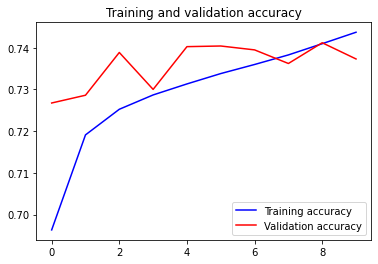

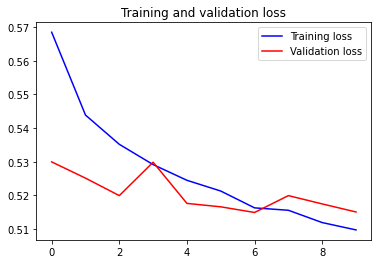

In [43]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
 
epochs = range(len(acc))
 
plt.plot(epochs, acc, 'b', label='Training accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()
 
plt.figure()
 
plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
 
plt.show()

In [47]:
yhat_classes = model.predict_classes(x_test, verbose=1)
yhat_classes

5398/5398 [==============================] - 5s 991us/step


array([1, 2, 1, ..., 1, 1, 1])

In [48]:
out_put = label_encoder.inverse_transform(yhat_classes)
out_put

array(['neutral', 'positive', 'neutral', ..., 'neutral', 'neutral',
       'neutral'], dtype=object)

In [49]:
data_dict = {'tweet_id':test_data["tweet_id"],'sentiment':out_put}
prediction = pd.DataFrame(data_dict)
prediction.to_csv('pred1.txt',index=False,sep=',')

**LSTM-CNN MODEL**

In [50]:
model = Sequential()
model.add(embedding_layer)
model.add(Conv1D(64, 5))
model.add(MaxPooling1D(5))
model.add(Dropout(0.2))
model.add(Conv1D(64, 5))
model.add(MaxPooling1D(5))
# LSTM layer with a hidden size of 64
model.add(Dropout(0.2))
model.add(LSTM(64, dropout=0.2, recurrent_dropout=0.2))
model.add(Dense(3))
model.add(Activation('softmax'))

model.summary()

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_1 (Embedding)      (None, 200, 200)          5686200   
_________________________________________________________________
conv1d_1 (Conv1D)            (None, 196, 64)           64064     
_________________________________________________________________
max_pooling1d_1 (MaxPooling1 (None, 39, 64)            0         
_________________________________________________________________
dropout_2 (Dropout)          (None, 39, 64)            0         
_________________________________________________________________
conv1d_2 (Conv1D)            (None, 35, 64)            20544     
_________________________________________________________________
max_pooling1d_2 (MaxPooling1 (None, 7, 64)             0         
_________________________________________________________________
dropout_3 (Dropout)          (None, 7, 64)            

In [51]:
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [52]:
callbacks = [ ReduceLROnPlateau(monitor='val_loss', patience=5, cooldown=0),
              EarlyStopping(monitor='val_accuracy', min_delta=1e-4, patience=5)]

In [53]:
history = model.fit(x_train, Y_train,
                    batch_size=64,
                    epochs=10,
                    validation_split=0.1,
                    verbose=1,
                    callbacks=callbacks)

Train on 19318 samples, validate on 2147 samples
Epoch 1/10
19318/19318 [==============================] - 35s 2ms/step - loss: 0.5594 - accuracy: 0.7061 - val_loss: 0.5413 - val_accuracy: 0.7177
Epoch 2/10
19318/19318 [==============================] - 35s 2ms/step - loss: 0.5333 - accuracy: 0.7281 - val_loss: 0.5387 - val_accuracy: 0.7199
Epoch 3/10
19318/19318 [==============================] - 35s 2ms/step - loss: 0.5207 - accuracy: 0.7371 - val_loss: 0.5336 - val_accuracy: 0.7227
Epoch 4/10
19318/19318 [==============================] - 35s 2ms/step - loss: 0.5111 - accuracy: 0.7437 - val_loss: 0.5361 - val_accuracy: 0.7198
Epoch 5/10
19318/19318 [==============================] - 35s 2ms/step - loss: 0.5003 - accuracy: 0.7515 - val_loss: 0.5437 - val_accuracy: 0.7210
Epoch 6/10
19318/19318 [==============================] - 35s 2ms/step - loss: 0.4887 - accuracy: 0.7607 - val_loss: 0.5365 - val_accuracy: 0.7243
Epoch 7/10
19318/19318 [==============================] - 34s 2ms/ste

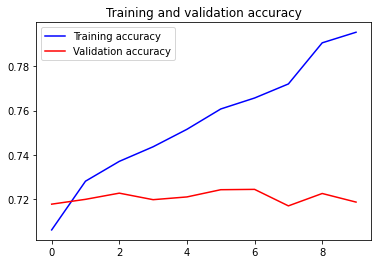

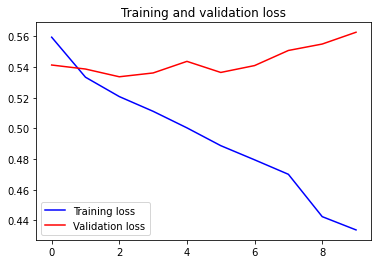

In [54]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
 
epochs = range(len(acc))
 
plt.plot(epochs, acc, 'b', label='Training accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()
 
plt.figure()
 
plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
 
plt.show()

In [55]:
yhat_classes = model.predict_classes(x_test, verbose=1)
yhat_classes

5398/5398 [==============================] - 3s 638us/step


array([1, 2, 1, ..., 1, 1, 1])

In [56]:
out_put = label_encoder.inverse_transform(yhat_classes)
out_put

array(['neutral', 'positive', 'neutral', ..., 'neutral', 'neutral',
       'neutral'], dtype=object)

In [57]:
data_dict = {'tweet_id':test_data["tweet_id"],'sentiment':out_put}
prediction = pd.DataFrame(data_dict)
prediction.to_csv('pred2.txt',index=False,sep=',')

**LSTM MODEL WITH DENSE LAYER**

In [58]:
model=Sequential()
model.add(embedding_layer)
model.add(LSTM(52, dropout=0.2, recurrent_dropout=0.2))
model.add(Dense(32))
model.add(Activation('relu'))
model.add(Dropout(0.5))
model.add(Dense(3))
model.add(Activation('softmax'))
model.summary()

Model: "sequential_3"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_1 (Embedding)      (None, 200, 200)          5686200   
_________________________________________________________________
lstm_3 (LSTM)                (None, 52)                52624     
_________________________________________________________________
dense_3 (Dense)              (None, 32)                1696      
_________________________________________________________________
activation_3 (Activation)    (None, 32)                0         
_________________________________________________________________
dropout_4 (Dropout)          (None, 32)                0         
_________________________________________________________________
dense_4 (Dense)              (None, 3)                 99        
_________________________________________________________________
activation_4 (Activation)    (None, 3)                

In [59]:
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [60]:
callbacks = [ ReduceLROnPlateau(monitor='val_loss', patience=5, cooldown=0),
              EarlyStopping(monitor='val_accuracy', min_delta=1e-4, patience=5)]

In [61]:
history = model.fit(x_train, Y_train,
                    batch_size=32,
                    epochs=10,
                    validation_split=0.1,
                    verbose=1,
                    callbacks=callbacks)

Train on 19318 samples, validate on 2147 samples
Epoch 1/10
19318/19318 [==============================] - 77s 4ms/step - loss: 0.5635 - accuracy: 0.7021 - val_loss: 0.5292 - val_accuracy: 0.7254
Epoch 2/10
19318/19318 [==============================] - 77s 4ms/step - loss: 0.5360 - accuracy: 0.7254 - val_loss: 0.5269 - val_accuracy: 0.7313
Epoch 3/10
19318/19318 [==============================] - 77s 4ms/step - loss: 0.5250 - accuracy: 0.7336 - val_loss: 0.5220 - val_accuracy: 0.7309
Epoch 4/10
19318/19318 [==============================] - 77s 4ms/step - loss: 0.5174 - accuracy: 0.7391 - val_loss: 0.5198 - val_accuracy: 0.7303
Epoch 5/10
19318/19318 [==============================] - 77s 4ms/step - loss: 0.5102 - accuracy: 0.7444 - val_loss: 0.5223 - val_accuracy: 0.7337
Epoch 6/10
19318/19318 [==============================] - 78s 4ms/step - loss: 0.5039 - accuracy: 0.7465 - val_loss: 0.5166 - val_accuracy: 0.7337
Epoch 7/10
19318/19318 [==============================] - 77s 4ms/ste

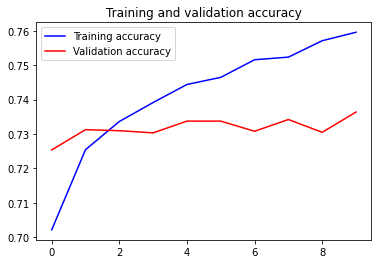

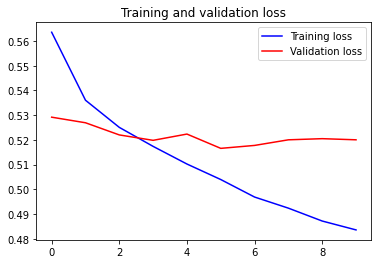

In [62]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
 
epochs = range(len(acc))
 
plt.plot(epochs, acc, 'b', label='Training accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()
 
plt.figure()
 
plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
 
plt.show()

In [63]:
yhat_classes = model.predict_classes(x_test, verbose=1)
yhat_classes

5398/5398 [==============================] - 5s 1ms/step


array([1, 2, 1, ..., 1, 1, 1])

In [64]:
out_put = label_encoder.inverse_transform(yhat_classes)
out_put

array(['neutral', 'positive', 'neutral', ..., 'neutral', 'neutral',
       'neutral'], dtype=object)

In [65]:
data_dict = {'tweet_id':test_data["tweet_id"],'sentiment':out_put}
prediction = pd.DataFrame(data_dict)
prediction.to_csv('pred3.txt',index=False,sep = ',')

**BIDIRECTIONAL RNN**

In [66]:
model = Sequential()
model.add(embedding_layer)
model.add(Dropout(0.5))
model.add(Bidirectional(SimpleRNN(32)))
model.add(Dropout(0.1))
model.add(Dense(3))
model.add(Activation('softmax'))

model.summary()

Model: "sequential_4"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_1 (Embedding)      (None, 200, 200)          5686200   
_________________________________________________________________
dropout_5 (Dropout)          (None, 200, 200)          0         
_________________________________________________________________
bidirectional_1 (Bidirection (None, 64)                14912     
_________________________________________________________________
dropout_6 (Dropout)          (None, 64)                0         
_________________________________________________________________
dense_5 (Dense)              (None, 3)                 195       
_________________________________________________________________
activation_5 (Activation)    (None, 3)                 0         
Total params: 5,701,307
Trainable params: 15,107
Non-trainable params: 5,686,200
_______________________________________

In [67]:
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [68]:
callbacks = [ ReduceLROnPlateau(monitor='val_loss', patience=5, cooldown=0),
              EarlyStopping(monitor='val_accuracy', min_delta=1e-4, patience=5)]

In [69]:
history = model.fit(x_train, Y_train,
                    batch_size=64,
                    epochs=10,
                    validation_split=0.1,
                    verbose=1,
                    callbacks=callbacks)

Train on 19318 samples, validate on 2147 samples
Epoch 1/10
19318/19318 [==============================] - 33s 2ms/step - loss: 0.6160 - accuracy: 0.6586 - val_loss: 0.5787 - val_accuracy: 0.6831
Epoch 2/10
19318/19318 [==============================] - 32s 2ms/step - loss: 0.5836 - accuracy: 0.6842 - val_loss: 0.5569 - val_accuracy: 0.7148
Epoch 3/10
19318/19318 [==============================] - 32s 2ms/step - loss: 0.5680 - accuracy: 0.7009 - val_loss: 0.5617 - val_accuracy: 0.7081
Epoch 4/10
19318/19318 [==============================] - 32s 2ms/step - loss: 0.5635 - accuracy: 0.7059 - val_loss: 0.5499 - val_accuracy: 0.7156
Epoch 5/10
19318/19318 [==============================] - 32s 2ms/step - loss: 0.5606 - accuracy: 0.7089 - val_loss: 0.5471 - val_accuracy: 0.7165
Epoch 6/10
19318/19318 [==============================] - 32s 2ms/step - loss: 0.5596 - accuracy: 0.7120 - val_loss: 0.5472 - val_accuracy: 0.7157
Epoch 7/10
19318/19318 [==============================] - 32s 2ms/ste

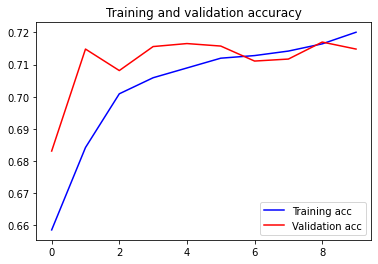

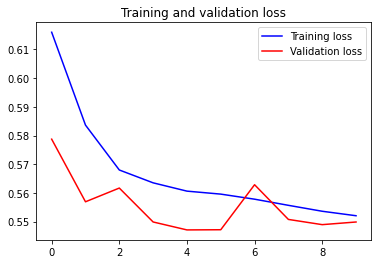

In [70]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
 
epochs = range(len(acc))
 
plt.plot(epochs, acc, 'b', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()
 
plt.figure()
 
plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
 
plt.show()



In [71]:
yhat_classes = model.predict_classes(x_test, verbose=1)
yhat_classes

5398/5398 [==============================] - 4s 709us/step


array([1, 2, 1, ..., 1, 1, 1])

In [72]:
out_put = label_encoder.inverse_transform(yhat_classes)
out_put

array(['neutral', 'positive', 'neutral', ..., 'neutral', 'neutral',
       'neutral'], dtype=object)

In [73]:
data_dict = {'tweet_id':test_data["tweet_id"],'sentiment':out_put}
prediction = pd.DataFrame(data_dict)
prediction.to_csv('pred4.txt',index=False,sep=',')

**BIDIRECTIONAL LSTM**

In [74]:
model = Sequential()
model.add(embedding_layer)
model.add(Bidirectional(LSTM(64)))
model.add(Dense(64))
model.add(Activation('relu'))
model.add(Dense(3))

model.summary()

Model: "sequential_5"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_1 (Embedding)      (None, 200, 200)          5686200   
_________________________________________________________________
bidirectional_2 (Bidirection (None, 128)               135680    
_________________________________________________________________
dense_6 (Dense)              (None, 64)                8256      
_________________________________________________________________
activation_6 (Activation)    (None, 64)                0         
_________________________________________________________________
dense_7 (Dense)              (None, 3)                 195       
Total params: 5,830,331
Trainable params: 144,131
Non-trainable params: 5,686,200
_________________________________________________________________


In [75]:
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [76]:
callbacks = [ ReduceLROnPlateau(monitor='val_loss', patience=5, cooldown=0),
              EarlyStopping(monitor='val_accuracy', min_delta=1e-4, patience=5)]

In [77]:
history = model.fit(x_train, Y_train,
                    batch_size=64,
                    epochs=10,
                    validation_split=0.1,
                    verbose=1,
                    callbacks=callbacks)

Train on 19318 samples, validate on 2147 samples
Epoch 1/10
19318/19318 [==============================] - 143s 7ms/step - loss: 0.6057 - accuracy: 0.7003 - val_loss: 0.5445 - val_accuracy: 0.7191
Epoch 2/10
19318/19318 [==============================] - 141s 7ms/step - loss: 0.5412 - accuracy: 0.7303 - val_loss: 0.5425 - val_accuracy: 0.7250
Epoch 3/10
19318/19318 [==============================] - 141s 7ms/step - loss: 0.5381 - accuracy: 0.7294 - val_loss: 0.5581 - val_accuracy: 0.7235
Epoch 4/10
19318/19318 [==============================] - 141s 7ms/step - loss: 0.5382 - accuracy: 0.7302 - val_loss: 0.5527 - val_accuracy: 0.7247
Epoch 5/10
19318/19318 [==============================] - 141s 7ms/step - loss: 0.5179 - accuracy: 0.7418 - val_loss: 0.5373 - val_accuracy: 0.7263
Epoch 6/10
19318/19318 [==============================] - 140s 7ms/step - loss: 0.5143 - accuracy: 0.7448 - val_loss: 0.5343 - val_accuracy: 0.7227
Epoch 7/10
19318/19318 [==============================] - 141s 

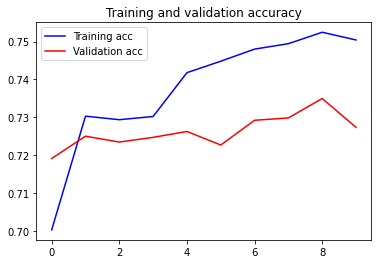

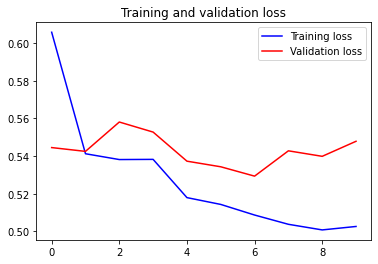

In [78]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
 
epochs = range(len(acc))
 
plt.plot(epochs, acc, 'b', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()
 
plt.figure()
 
plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
 
plt.show()

In [79]:
yhat_classes = model.predict_classes(x_test, verbose=1)
yhat_classes

5398/5398 [==============================] - 11s 2ms/step


array([1, 2, 1, ..., 1, 1, 1])

In [80]:
out_put = label_encoder.inverse_transform(yhat_classes)
out_put

array(['neutral', 'positive', 'neutral', ..., 'neutral', 'neutral',
       'neutral'], dtype=object)

In [81]:
data_dict = {'tweet_id':test_data["tweet_id"],'sentiment':out_put}
prediction = pd.DataFrame(data_dict)
prediction.to_csv('pred5.txt',index=False,sep=',')

**TWO BIDIRECTIONAL LSTM LAYER**

In [91]:
model = Sequential()
model.add(embedding_layer)
model.add(Bidirectional(LSTM(64,return_sequences = True)))
model.add(Bidirectional(LSTM(32)))
model.add(Dense(64))
model.add(Activation('relu'))
model.add(Dropout(0.5))
model.add(Dense(3))

model.summary()

Model: "sequential_9"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_1 (Embedding)      (None, 200, 200)          5686200   
_________________________________________________________________
bidirectional_9 (Bidirection (None, 200, 128)          135680    
_________________________________________________________________
bidirectional_10 (Bidirectio (None, 64)                41216     
_________________________________________________________________
dense_12 (Dense)             (None, 64)                4160      
_________________________________________________________________
activation_9 (Activation)    (None, 64)                0         
_________________________________________________________________
dropout_9 (Dropout)          (None, 64)                0         
_________________________________________________________________
dense_13 (Dense)             (None, 3)                

In [92]:
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [93]:
callbacks = [ ReduceLROnPlateau(monitor='val_loss', patience=5, cooldown=0),
              EarlyStopping(monitor='val_accuracy', min_delta=1e-4, patience=5)]

In [94]:
history = model.fit(x_train, Y_train,
                    batch_size=64,
                    epochs=10,
                    validation_split=0.1,
                    verbose=1,
                    callbacks=callbacks)

Train on 19318 samples, validate on 2147 samples
Epoch 1/10
19318/19318 [==============================] - 224s 12ms/step - loss: 0.6774 - accuracy: 0.6672 - val_loss: 0.5772 - val_accuracy: 0.6855
Epoch 2/10
19318/19318 [==============================] - 221s 11ms/step - loss: 0.5888 - accuracy: 0.6891 - val_loss: 0.5489 - val_accuracy: 0.7120
Epoch 3/10
19318/19318 [==============================] - 221s 11ms/step - loss: 0.5651 - accuracy: 0.7108 - val_loss: 0.5316 - val_accuracy: 0.7274
Epoch 4/10
19318/19318 [==============================] - 220s 11ms/step - loss: 0.5767 - accuracy: 0.6993 - val_loss: 0.5322 - val_accuracy: 0.7272
Epoch 5/10
19318/19318 [==============================] - 220s 11ms/step - loss: 0.5574 - accuracy: 0.7119 - val_loss: 0.5272 - val_accuracy: 0.7271
Epoch 6/10
19318/19318 [==============================] - 219s 11ms/step - loss: 0.5526 - accuracy: 0.7141 - val_loss: 0.5234 - val_accuracy: 0.7325
Epoch 7/10
19318/19318 [==============================] -

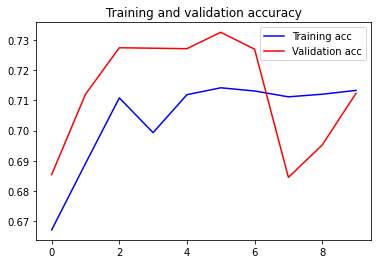

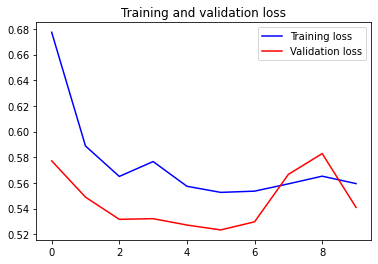

In [95]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
 
epochs = range(len(acc))
 
plt.plot(epochs, acc, 'b', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()
 
plt.figure()
 
plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
 
plt.show()

In [96]:
yhat_classes = model.predict_classes(x_test, verbose=1)
yhat_classes

5398/5398 [==============================] - 16s 3ms/step


array([2, 2, 1, ..., 1, 1, 1])

In [97]:
out_put = label_encoder.inverse_transform(yhat_classes)
out_put

array(['positive', 'positive', 'neutral', ..., 'neutral', 'neutral',
       'neutral'], dtype=object)

In [98]:
data_dict = {'tweet_id':test_data["tweet_id"],'sentiment':out_put}
prediction = pd.DataFrame(data_dict)
prediction.to_csv('pred6.txt',index=False,sep=',')